In [14]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn import datasets
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, silhouette_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

!pip install yfinance

### 1. Google 주가 데이터를 가져와서, LSTM 모델을 학습하여 주가 예측
### 2. 과거 20일 데이터를 기반으로 다음날 주가를 예측(21일차)
### 3. LSTM 2개를 사용하여 시계열 데이터 학습
### 4. 학습 데이터 80%, 테스트 데이터 20%로 분할
### 5. 그래프

In [4]:
import yfinance as yf

In [5]:
name = 'GOOG'  #'GOOG'-구글, AAPL-애플

start_day = '2020-01-01'
end_day = '2026-02-03'

stock = yf.download(name, start=start_day, end=end_day)

[*********************100%***********************]  1 of 1 completed


In [6]:
print(stock.shape)
stock.head()

(1529, 5)


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2020-01-02,67.859535,67.897747,66.578146,66.578146,28132000
2020-01-03,67.526527,68.114123,66.776356,66.891292,23728000
2020-01-06,69.191559,69.305201,66.997512,66.997512,34646000
2020-01-07,69.148376,69.627283,69.001476,69.376668,30054000
2020-01-08,69.693298,70.053595,69.024312,69.085847,30560000


In [7]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1529 entries, 2020-01-02 to 2026-02-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GOOG)   1529 non-null   float64
 1   (High, GOOG)    1529 non-null   float64
 2   (Low, GOOG)     1529 non-null   float64
 3   (Open, GOOG)    1529 non-null   float64
 4   (Volume, GOOG)  1529 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 71.7 KB


In [8]:
stock2 = pd.DataFrame(stock['Close'])
stock2.head()

Ticker,GOOG
Date,
2020-01-02,67.859535
2020-01-03,67.526527
2020-01-06,69.191559
2020-01-07,69.148376
2020-01-08,69.693298


In [ ]:
# 데이터를 csv파일로 저장

stock2.to_csv(f'../../data/{name}.csv')

In [10]:
stock_values = stock2.values
print(stock_values[0])

[67.85953522]


In [11]:
#### 0~1 범위로 스케일링, 데이터를 0~1 범위로 정규화 
####    ==> LSTM이나 신경망 학습 시 입력값을 균일하게 만들기 위해 사용

from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
stock_values_scaled=scaler.fit_transform(stock_values)

stock_values_scaled[0]

array([0.05273099])

In [12]:
n_train = int(len(stock_values)*0.8)
n_test = len(stock_values) - n_train

print(n_train, n_test)

1223 306


In [16]:
X_train,Y_train=[],[]

#20일 구간의 주가를 x 값으로하고, 그 다음날 값을 y 값으로 정리
for i in range(20, n_train):
    X_train.append(stock_values_scaled[i-20:i,0])
    Y_train.append(stock_values_scaled[i,0]) 

X_train

[array([0.05273099, 0.05159235, 0.0572855 , 0.05713785, 0.05900107,
        0.06163294, 0.06331282, 0.06492491, 0.063508  , 0.06491982,
        0.06704091, 0.07190933, 0.07258977, 0.07285281, 0.07297158,
        0.06958799, 0.06402045, 0.06718689, 0.0682169 , 0.06774345]),
 array([0.05159235, 0.0572855 , 0.05713785, 0.05900107, 0.06163294,
        0.06331282, 0.06492491, 0.063508  , 0.06491982, 0.06704091,
        0.07190933, 0.07258977, 0.07285281, 0.07297158, 0.06958799,
        0.06402045, 0.06718689, 0.0682169 , 0.06774345, 0.06407646]),
 array([0.0572855 , 0.05713785, 0.05900107, 0.06163294, 0.06331282,
        0.06492491, 0.063508  , 0.06491982, 0.06704091, 0.07190933,
        0.07258977, 0.07285281, 0.07297158, 0.06958799, 0.06402045,
        0.06718689, 0.0682169 , 0.06774345, 0.06407646, 0.07285108]),
 array([0.05713785, 0.05900107, 0.06163294, 0.06331282, 0.06492491,
        0.063508  , 0.06491982, 0.06704091, 0.07190933, 0.07258977,
        0.07285281, 0.07297158, 0.06958799

In [17]:
X_train1, Y_train1 = np.array(X_train), np.array(Y_train)   # 리스트를 넘파이 배열로 변환
X_train2 = np.reshape(X_train1, (X_train1.shape[0],X_train1.shape[1],1))   # LSTM에 입력하기 위해 (샘플 수, 타임스텝 수, 특징 수)로 reshape

print(X_train2.shape) 
X_train2

(1203, 20, 1)


array([[[0.05273099],
        [0.05159235],
        [0.0572855 ],
        ...,
        [0.06718689],
        [0.0682169 ],
        [0.06774345]],

       [[0.05159235],
        [0.0572855 ],
        [0.05713785],
        ...,
        [0.0682169 ],
        [0.06774345],
        [0.06407646]],

       [[0.0572855 ],
        [0.05713785],
        [0.05900107],
        ...,
        [0.06774345],
        [0.06407646],
        [0.07285108]],

       ...,

       [[0.37545314],
        [0.37586134],
        [0.38042026],
        ...,
        [0.40807949],
        [0.40137733],
        [0.40386089]],

       [[0.37586134],
        [0.38042026],
        [0.38664618],
        ...,
        [0.40137733],
        [0.40386089],
        [0.42740357]],

       [[0.38042026],
        [0.38664618],
        [0.38851728],
        ...,
        [0.40386089],
        [0.42740357],
        [0.44084196]]], shape=(1203, 20, 1))

In [18]:
## LSTM 모델 구축 및 실행

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input


# 모델 생성
lstm_stock = Sequential([
    Input(shape=(X_train2.shape[1], 1)),     # 20일간의 종가 시퀀스를 입력 (1개의 특징만 있음)
    LSTM(units=30, return_sequences=True),
    LSTM(units=30, return_sequences=False),
    Dense(1)
])

lstm_stock.compile(loss='mse', optimizer='adam')

lstm_stock.fit(X_train2, Y_train1, epochs=10, batch_size=1, verbose=1)

2026-02-04 21:09:51.479483: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - loss: 7.1763e-04
Epoch 2/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 2.9929e-04
Epoch 3/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 2.3099e-04
Epoch 4/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 30s 25ms/step - loss: 1.8588e-04
Epoch 5/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - loss: 1.5828e-04
Epoch 6/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - loss: 1.2913e-04
Epoch 7/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 19s 16ms/step - loss: 1.1598e-04
Epoch 8/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 9.9429e-05
Epoch 9/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - loss: 1.0984e-04
Epoch 10/10
1203/1203 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 9.0394e-05


In [19]:
## 평가용 데이터 

stock_test = stock_values_scaled[n_train-20:]
X_test = []

# 테스트용 시퀀스를 생성, 20일치 입력 → 다음 날 예측 형태로 구성됨
for i in range(20, len(stock_test)):
  X_test.append(stock_test[i-20:i,0])

X_test[0]

array([0.38664618, 0.38851728, 0.38797301, 0.38038619, 0.38222338,
       0.38477503, 0.38824515, 0.38028414, 0.38045428, 0.38882349,
       0.39341638, 0.40294232, 0.41995293, 0.40821561, 0.40807949,
       0.40137733, 0.40386089, 0.42740357, 0.44084196, 0.43260882])

In [20]:
## LSTM 모델의 입력층의 구조로 변형_reshape()
X_test = np.array(X_test)   # X_test: 리스트 → 넘파이 배열로 변환
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1)) 

print(X_test.shape) 
print(X_test[0])

(306, 20, 1)
[[0.38664618]
 [0.38851728]
 [0.38797301]
 [0.38038619]
 [0.38222338]
 [0.38477503]
 [0.38824515]
 [0.38028414]
 [0.38045428]
 [0.38882349]
 [0.39341638]
 [0.40294232]
 [0.41995293]
 [0.40821561]
 [0.40807949]
 [0.40137733]
 [0.40386089]
 [0.42740357]
 [0.44084196]
 [0.43260882]]


In [21]:
## LSTM 모델의 입력층의 구조로 변형_reshape()
X_test = np.array(X_test)   # X_test: 리스트 → 넘파이 배열로 변환
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1)) 

print(X_test.shape) 
print(X_test[0])

(306, 20, 1)
[[0.38664618]
 [0.38851728]
 [0.38797301]
 [0.38038619]
 [0.38222338]
 [0.38477503]
 [0.38824515]
 [0.38028414]
 [0.38045428]
 [0.38882349]
 [0.39341638]
 [0.40294232]
 [0.41995293]
 [0.40821561]
 [0.40807949]
 [0.40137733]
 [0.40386089]
 [0.42740357]
 [0.44084196]
 [0.43260882]]


In [22]:
## 모델 예측 실행
predicted_value = lstm_stock.predict(X_test)

predicted_value

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


array([[0.42469868],
       [0.4349811 ],
       [0.438709  ],
       [0.4277985 ],
       [0.41847825],
       [0.40750203],
       [0.42001352],
       [0.42772105],
       [0.41759238],
       [0.3895452 ],
       [0.38458124],
       [0.3954408 ],
       [0.39764237],
       [0.39753947],
       [0.396142  ],
       [0.4054578 ],
       [0.4043183 ],
       [0.41593012],
       [0.40774494],
       [0.4173494 ],
       [0.4189744 ],
       [0.454004  ],
       [0.48637715],
       [0.46807086],
       [0.46450755],
       [0.492769  ],
       [0.4828374 ],
       [0.4585584 ],
       [0.4629392 ],
       [0.4744048 ],
       [0.48296908],
       [0.48666102],
       [0.4839668 ],
       [0.47312874],
       [0.47097993],
       [0.462988  ],
       [0.46546403],
       [0.47423103],
       [0.49059752],
       [0.48169816],
       [0.4790237 ],
       [0.4715835 ],
       [0.4702404 ],
       [0.4657411 ],
       [0.4895032 ],
       [0.47357327],
       [0.489502  ],
       [0.493

In [23]:
## 예측값을 스케일링 이전 값(원래 주가)으로 되돌림

predicted_value = scaler.inverse_transform(predicted_value)   # 예측값 복원

predicted_value

array([[176.64606],
       [179.65327],
       [180.74355],
       [177.55264],
       [174.82681],
       [171.61668],
       [175.27583],
       [177.52998],
       [174.56773],
       [166.36499],
       [164.91322],
       [168.08923],
       [168.73311],
       [168.70302],
       [168.2943 ],
       [171.01881],
       [170.68556],
       [174.08159],
       [171.68773],
       [174.49666],
       [174.97191],
       [185.21675],
       [194.6847 ],
       [189.33078],
       [188.28865],
       [196.55405],
       [193.64944],
       [186.54875],
       [187.82996],
       [191.18323],
       [193.68796],
       [194.7677 ],
       [193.97975],
       [190.81001],
       [190.18156],
       [187.84424],
       [188.56839],
       [191.1324 ],
       [195.91899],
       [193.31625],
       [192.53407],
       [190.3581 ],
       [189.96529],
       [188.64941],
       [195.59894],
       [190.94003],
       [195.59859],
       [196.90875],
       [197.09691],
       [196.64172],


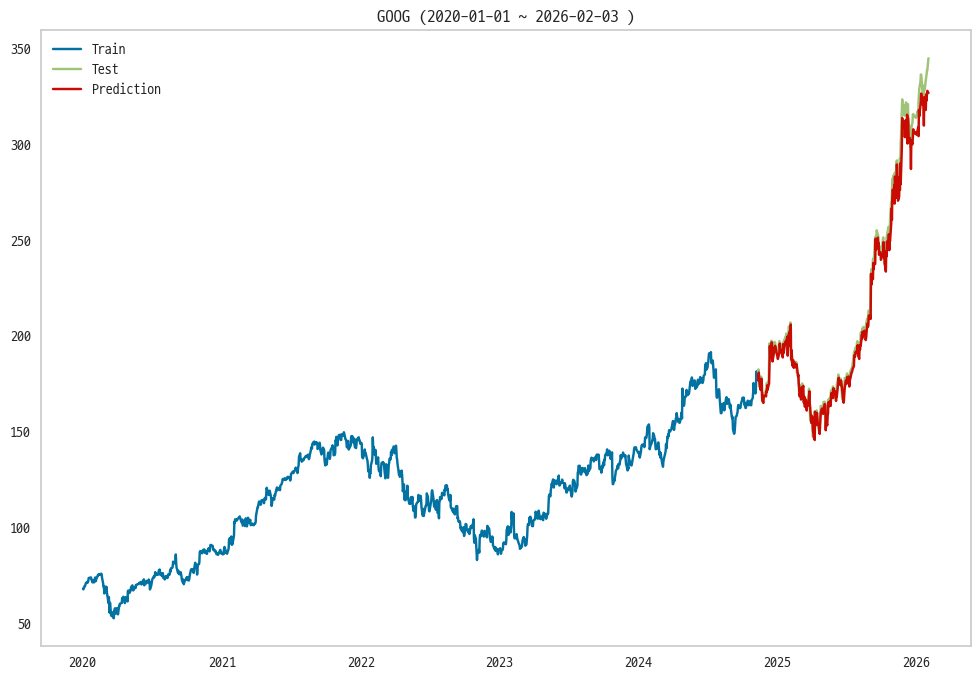

In [24]:
stock_train_vis = stock[:n_train].copy()  # 훈련 데이터 복사
stock_test_vis = stock[n_train:].copy()   # 테스트 데이터 복사

stock_test_vis['Predictions'] = predicted_value    # 예측값

plt.figure(figsize = (12,8))
plt.grid(False)
plt.plot(stock_train_vis['Close'], label = 'Train')
plt.plot(stock_test_vis['Close'], label = 'Test')
plt.plot(stock_test_vis['Predictions'], label = 'Prediction')
plt.legend()
plt.title(name + ' (' + start_day + ' ~ ' + end_day + ' )')
plt.show()